<a href="https://colab.research.google.com/github/Amri1003/Deep_Learning_Projects/blob/main/Working_withAnimal_Images.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
uploaded = files.upload()

for fn in uploaded.keys():
  print(f'User uploaded file "{fn}" with length {len(uploaded[fn])} bytes')

Saving leopard(1).jpg to leopard(1).jpg
User uploaded file "leopard(1).jpg" with length 10732 bytes


In [ ]:
import tensorflow

import keras

from skimage import io

import random

import numpy as np

import matplotlib.pyplot as plt

from numpy import expand_dims

from tensorflow.keras.preprocessing.image import ImageDataGenerator






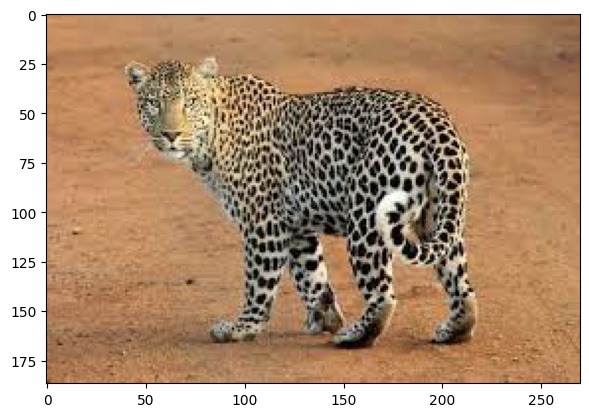

In [ ]:
image = io.imread('leopard(1).jpg')

i, (im1) = plt.subplots(1)

i.set_figwidth(15)

im1.imshow(image)






In [ ]:
# print shape of image

print(image.shape)






(187, 270, 3)


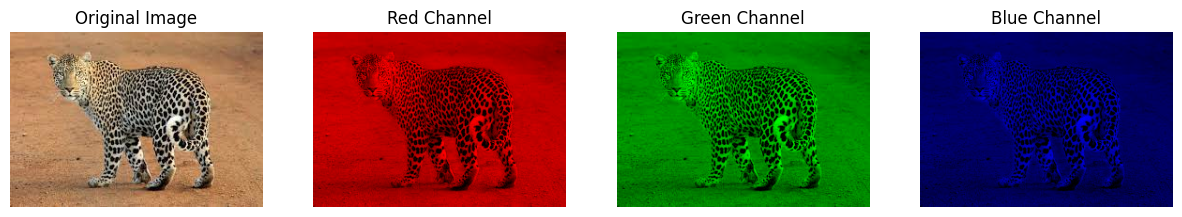

In [ ]:
# Extract individual channels

R, G, B = image[:, :, 0], image[:, :, 1], image[:, :, 2]

# Create blank images for visualization

zeros = np.zeros_like(R)

# Convert single channels into three-channel images

R_img = np.stack([R, zeros, zeros], axis=-1)  # Red channel

G_img = np.stack([zeros, G, zeros], axis=-1)  # Green channel

B_img = np.stack([zeros, zeros, B], axis=-1)  # Blue channel

# Display images

fig, axes = plt.subplots(1, 4, figsize=(15, 5))

axes[0].imshow(image)

axes[0].set_title('Original Image')

axes[1].imshow(R_img)

axes[1].set_title('Red Channel')

axes[2].imshow(G_img)

axes[2].set_title('Green Channel')

axes[3].imshow(B_img)

axes[3].set_title('Blue Channel')

# Remove axes

for ax in axes:

    ax.axis('off')

plt.show()






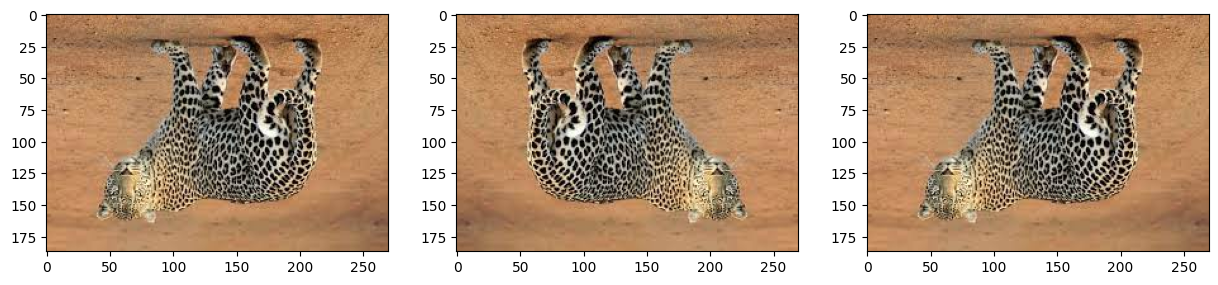

In [ ]:
samples = expand_dims(image,0)

datagen = ImageDataGenerator(horizontal_flip=True, vertical_flip=True)

it = datagen.flow(samples, batch_size=1)

fig, im = plt.subplots(nrows=1, ncols=3, figsize=(15,15))

for i in range(3):

    modified_image = next(it)[0].astype('uint8')

    im[i].imshow(modified_image)






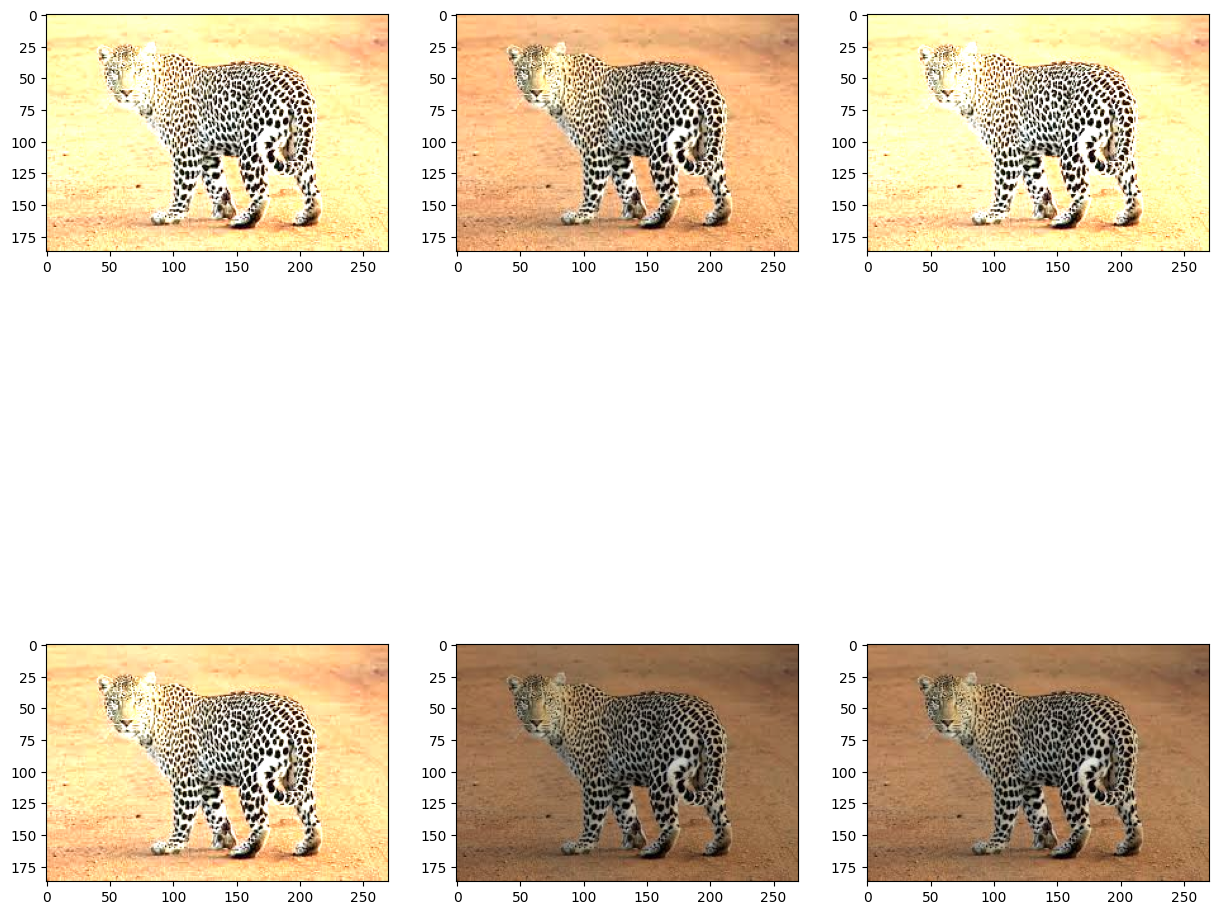

In [ ]:
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing.image import ImageDataGenerator

from numpy import expand_dims

datagen = ImageDataGenerator(brightness_range=[0.5,2.0])

it = datagen.flow(samples, batch_size=1)

fig, im = plt.subplots(nrows=2, ncols=3, figsize=(15,15))

# Iterate through subplots using row and column indices

for i in range(2):  # Iterate over rows

    for j in range(3):  # Iterate over columns

        modified_image = next(it)[0].astype('uint8')

        im[i, j].imshow(modified_image)  # Access subplot using [row, col]

plt.show()






Cat Dog Image classfication using CNN



Steps

Load the data
Visualization of Images
Image Augmentation
Create Train set & test Set
Create CNN Arch
Compile the model
Evalute & predict

In [ ]:
# mount google drive

from google.colab import drive

drive.mount('/content/drive')






Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# load the dataset

import zipfile

zip_ref = zipfile.ZipFile("/content/drive/MyDrive/training_set.zip", 'r')

zip_ref.extractall("/content")

zip_ref.close()






In [ ]:
# extract test data

zip_ref = zipfile.ZipFile("/content/drive/MyDrive/test_set.zip", 'r')

zip_ref.extractall("/content")

zip_ref.close()






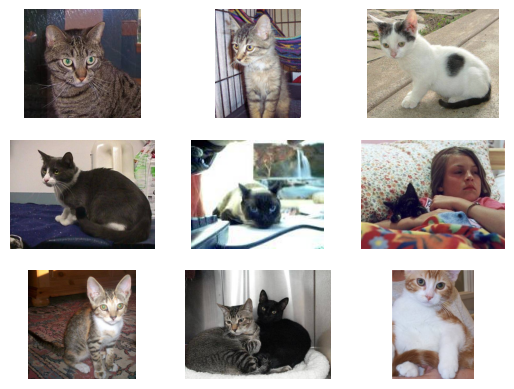

In [ ]:
# print some images from training data

import matplotlib.pyplot as plt

from matplotlib.image import imread

Folder='/content/training_set/cats/'

for i in range(9):

  plt.subplot(331+i)

  filename=Folder+'cat.'+str(i+1)+'.jpg' # Folder/cat.1.jpg

  image=imread(filename)

  plt.imshow(image)

  plt.axis('off')

plt.show()






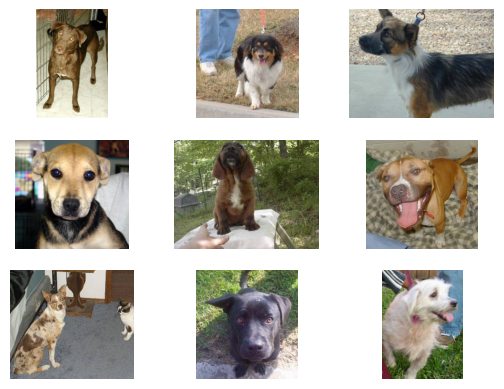

In [ ]:
# print some images from training data

import matplotlib.pyplot as plt

from matplotlib.image import imread

Folder='/content/training_set/dogs/'

for i in range(9):

  plt.subplot(331+i)

  filename=Folder+'dog.'+str(i+1)+'.jpg' # Folder/cat.1.jpg

  image=imread(filename)

  plt.imshow(image)

  plt.axis('off')

plt.show()






In [ ]:
# generate more images by applying some transformation on images

from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen=ImageDataGenerator(

    rescale=1./255,

    shear_range=0.2,

    zoom_range=0.2,

    horizontal_flip=True

)






Create test set and train set

In [ ]:
test_datagen=ImageDataGenerator(

    rescale=1./255

)






In [ ]:
training_set=train_datagen.flow_from_directory(

    '/content/training_set',

    target_size=(64,64),

    batch_size=32,

    class_mode='binary'

)






Found 8005 images belonging to 2 classes.


In [ ]:
# create test set

test_set=test_datagen.flow_from_directory(

    '/content/test_set',

    target_size=(64,64),

    batch_size=32,

    class_mode='binary'

)






Found 2023 images belonging to 2 classes.


In [ ]:
# print the name of classes

training_set.class_indices






{'cats': 0, 'dogs': 1}

In [ ]:
# import library

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import Conv2D,MaxPooling2D,Flatten,Dense,Dropout

print('Library imported')






Library imported


In [ ]:
model=Sequential()

# add first conv layer

model.add(Conv2D(64,(3,3),activation='relu',input_shape=(64,64,3)))

model.add(MaxPooling2D(2,2))

model.add(Dropout(0.2))

# second conv layer

model.add(Conv2D(128,(3,3),activation='relu'))

model.add(MaxPooling2D(2,2))

model.add(Dropout(0.2))

# third conv layer

model.add(Conv2D(32,(3,3),activation='relu'))

model.add(MaxPooling2D(2,2))

model.add(Dropout(0.2))

# FCN

model.add(Flatten())

model.add(Dense(128,activation='relu'))

model.add(Dense(1,activation='sigmoid'))

model.summary()






/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 31, 31, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 32)     │        36,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 6, 6, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 260,257 (1016.63 KB)

 Trainable params: 260,257 (1016.63 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# compile the model

model.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])

print('model compiled')






model compiled


In [ ]:
# run the model

history=model.fit(training_set,epochs=5,validation_data=test_set)






Epoch 1/5
251/251 ━━━━━━━━━━━━━━━━━━━━ 37s 117ms/step - accuracy: 0.5343 - loss: 0.6887 - val_accuracy: 0.6218 - val_loss: 0.6703
Epoch 2/5
251/251 ━━━━━━━━━━━━━━━━━━━━ 23s 91ms/step - accuracy: 0.6111 - loss: 0.6548 - val_accuracy: 0.6683 - val_loss: 0.6367
Epoch 3/5
251/251 ━━━━━━━━━━━━━━━━━━━━ 24s 95ms/step - accuracy: 0.6702 - loss: 0.6089 - val_accuracy: 0.6767 - val_loss: 0.6006
Epoch 4/5
251/251 ━━━━━━━━━━━━━━━━━━━━ 23s 93ms/step - accuracy: 0.6932 - loss: 0.5791 - val_accuracy: 0.7375 - val_loss: 0.5287
Epoch 5/5
251/251 ━━━━━━━━━━━━━━━━━━━━ 22s 87ms/step - accuracy: 0.7183 - loss: 0.5513 - val_accuracy: 0.7449 - val_loss: 0.5095


Text(0.5, 0, 'epoch')

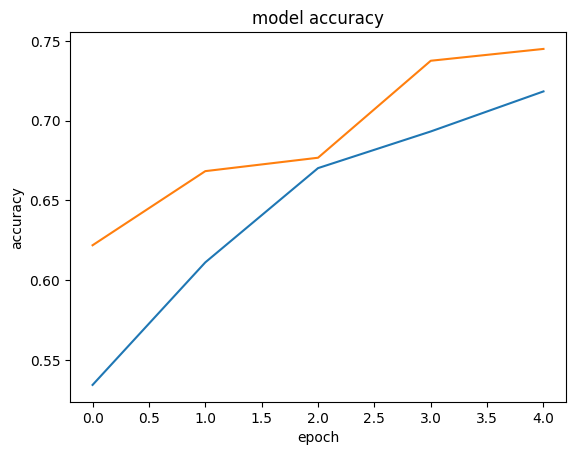

In [ ]:
# plot the accuracy and loss chart

import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])

plt.plot(history.history['val_accuracy'])

plt.title('model accuracy')

plt.ylabel('accuracy')

plt.xlabel('epoch')






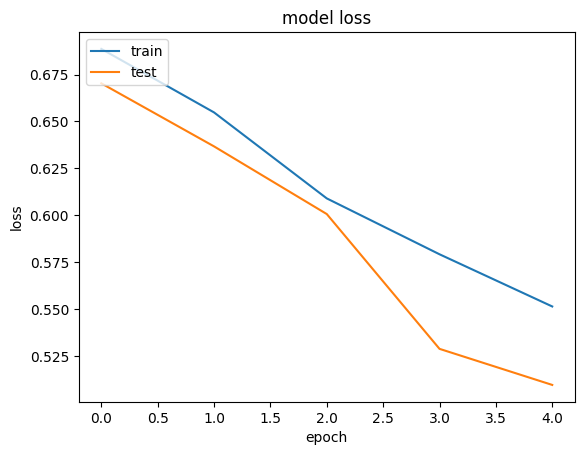

In [ ]:
# print loss graph

plt.plot(history.history['loss'])

plt.plot(history.history['val_loss'])

plt.title('model loss')

plt.ylabel('loss')

plt.xlabel('epoch')

plt.legend(['train', 'test'], loc='upper left')

plt.show()






In [ ]:
# evaluate the test accuracy

model.evaluate(test_set)






64/64 ━━━━━━━━━━━━━━━━━━━━ 3s 48ms/step - accuracy: 0.7449 - loss: 0.5095


[0.5094667673110962, 0.7449332475662231]

In [ ]:
# evaluate the train accuracy

model.evaluate(training_set)






251/251 ━━━━━━━━━━━━━━━━━━━━ 20s 80ms/step - accuracy: 0.7538 - loss: 0.5026


[0.5026082992553711, 0.753778874874115]

In [ ]:
# Change something and re run

In [ ]:
# save the model

model.save('cat_dog.keras')

print('model saved successfully')






model saved successfully


In [ ]:
# load the model

from tensorflow.keras.models import load_model

model=load_model('/content/cat_dog.keras')

print('model loaded')






model loaded


In [ ]:
import pandas as pd

test_set.reset

y_pred_prob=model.predict(test_set)

print(y_pred_prob)






64/64 ━━━━━━━━━━━━━━━━━━━━ 3s 42ms/step
[[0.791232  ]
 [0.48347175]
 [0.41658375]
 ...
 [0.87139344]
 [0.40220064]
 [0.4373668 ]]


In [ ]:
df=pd.DataFrame({'filename':test_set.filenames,

                 'predict':y_pred_prob[:,0],

                 'y':test_set.classes})

pd.set_option('display.float_format',lambda x:'%.5f' %x)

df['y_pred']=df['predict']>0.5

df['y_pred']=df['y_pred'].astype(int)

df






,filename,predict,y,y_pred
0,cats/cat.4001.jpg,0.79123,0,1
1,cats/cat.4002.jpg,0.48347,0,0
2,cats/cat.4003.jpg,0.41658,0,0
3,cats/cat.4004.jpg,0.31930,0,0
4,cats/cat.4005.jpg,0.58555,0,1
...,...,...,...,...
2018,dogs/dog.4996.jpg,0.10151,1,0
2019,dogs/dog.4997.jpg,0.22713,1,0
2020,dogs/dog.4998.jpg,0.87139,1,1
2021,dogs/dog.4999.jpg,0.40220,1,0


In [ ]:
# print num of dog and cats in test set data

df['y'].value_counts()






,count
y,
1,1012
0,1011


In [ ]:
#pred data

df['y_pred'].value_counts()






,count
y_pred,
1,1022
0,1001


Saving d1.jfif to d1.jfif
User uploaded file "d1.jfif" with length 4788 bytes


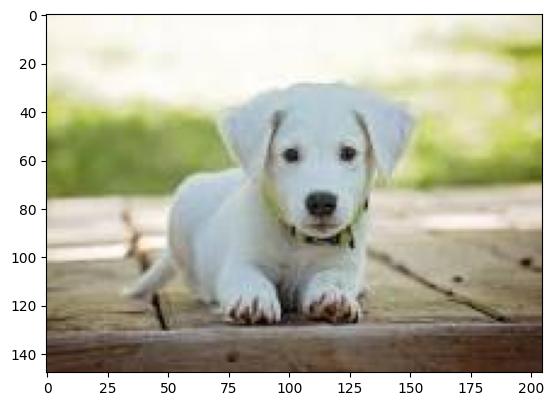

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 625ms/step
[[0.00318438]]
cat


In [ ]:
# pred on new data

# do pred on new image
from google.colab import files
uploaded = files.upload()

for fn in uploaded.keys():
  print(f'User uploaded file "{fn}" with length {len(uploaded[fn])} bytes')

from tensorflow.keras.preprocessing.image import load_img

from tensorflow.keras.preprocessing.image import img_to_array

from tensorflow.keras.models import load_model

import numpy as np

test_image=load_img('/content/d1.jfif')

plt.imshow(test_image)

plt.show()

test_image=load_img('/content/d1.jfif',target_size=(64,64))

test_image=img_to_array(test_image)

test_image=np.expand_dims(test_image,axis=0)

result=model.predict(test_image)

print(result)

if result[0][0]==1:

  prediction='dog'

else:

  prediction='cat'

print(prediction)






In [ ]:
# write few things as text from desktop

Transfer Learning

Already pre trained CNN models --trained on millions of images, 1000 of classes.
Feature Extraction--

Use pre trained models for extracting the features, pass to ANN.Pre trained model will not be trained again





In [ ]:
import tensorflow as tf

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import Dense, Flatten

from tensorflow.keras.applications.vgg16 import VGG16

print('imported')






imported


In [ ]:
vgg_model=VGG16(weights='imagenet',

    include_top=False, # adding own CNN

    input_shape=(64,64,3),

        name='vgg16')






In [ ]:
vgg_model.trainable=False






In [ ]:
vgg_model.summary()






Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 64, 64, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 16, 16, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 16, 16, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 8, 8, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 4, 4, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 4, 4, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 4, 4, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 4, 4, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 2, 2, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 14,714,688 (56.13 MB)

In [ ]:
# complete model

model=Sequential()

# feature extraction

model.add(vgg_model)

# FCN

model.add(Flatten())

model.add(Dense(128,activation='relu'))

model.add(Dense(1,activation='sigmoid'))

model.summary()






Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 2, 2, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,977,089 (57.13 MB)

 Trainable params: 262,401 (1.00 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [ ]:
# compile the model

model.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])

print('model compiled')






model compiled


In [ ]:
# run the model

history=model.fit(training_set,epochs=5,validation_data=test_set)






Epoch 1/5
251/251 ━━━━━━━━━━━━━━━━━━━━ 33s 115ms/step - accuracy: 0.7399 - loss: 0.5185 - val_accuracy: 0.7993 - val_loss: 0.4350
Epoch 2/5
251/251 ━━━━━━━━━━━━━━━━━━━━ 26s 102ms/step - accuracy: 0.7833 - loss: 0.4484 - val_accuracy: 0.7929 - val_loss: 0.4350
Epoch 3/5
251/251 ━━━━━━━━━━━━━━━━━━━━ 26s 103ms/step - accuracy: 0.7955 - loss: 0.4379 - val_accuracy: 0.7958 - val_loss: 0.4258
Epoch 4/5
251/251 ━━━━━━━━━━━━━━━━━━━━ 24s 95ms/step - accuracy: 0.8011 - loss: 0.4167 - val_accuracy: 0.8062 - val_loss: 0.4103
Epoch 5/5
251/251 ━━━━━━━━━━━━━━━━━━━━ 24s 97ms/step - accuracy: 0.8072 - loss: 0.4085 - val_accuracy: 0.8171 - val_loss: 0.4076


In [ ]:
# do experiment instead of 64 make it 150
#Change the input dim of data , VGG trained with 224*224






In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen=ImageDataGenerator(

    rescale=1./255,

    shear_range=0.2,

    zoom_range=0.2,

    horizontal_flip=True

)

test_datagen=ImageDataGenerator(

    rescale=1./255

)

training_set=train_datagen.flow_from_directory(

    '/content/training_set',

    target_size=(150,150),

    batch_size=32,

    class_mode='binary'

)

# create test set

test_set=test_datagen.flow_from_directory(

    '/content/test_set',

    target_size=(150,150),

    batch_size=32,

    class_mode='binary'

)






Found 8005 images belonging to 2 classes.
Found 2023 images belonging to 2 classes.


In [ ]:
vgg_model=VGG16(weights='imagenet',

    include_top=False,

    input_shape=(150,150,3),

        name='vgg16')






In [ ]:
vgg_model.trainable=False






In [ ]:
# complete model

model=Sequential()

# feature extraction

model.add(vgg_model)

# FCN

model.add(Flatten())

model.add(Dense(128,activation='relu'))

model.add(Dense(1,activation='sigmoid'))

model.summary()






Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 4, 4, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │     1,048,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,763,521 (60.13 MB)

 Trainable params: 1,048,833 (4.00 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [ ]:
# compile the model

model.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])

print('model compiled')






model compiled


In [ ]:
# run the model

history=model.fit(training_set,epochs=5,validation_data=test_set)






Epoch 1/5
251/251 ━━━━━━━━━━━━━━━━━━━━ 87s 300ms/step - accuracy: 0.8487 - loss: 0.3387 - val_accuracy: 0.8947 - val_loss: 0.2600
Epoch 2/5
251/251 ━━━━━━━━━━━━━━━━━━━━ 69s 273ms/step - accuracy: 0.8963 - loss: 0.2505 - val_accuracy: 0.9046 - val_loss: 0.2366
Epoch 3/5
251/251 ━━━━━━━━━━━━━━━━━━━━ 67s 269ms/step - accuracy: 0.9037 - loss: 0.2264 - val_accuracy: 0.8992 - val_loss: 0.2465
Epoch 4/5
251/251 ━━━━━━━━━━━━━━━━━━━━ 67s 266ms/step - accuracy: 0.9094 - loss: 0.2116 - val_accuracy: 0.8992 - val_loss: 0.2482
Epoch 5/5
251/251 ━━━━━━━━━━━━━━━━━━━━ 67s 266ms/step - accuracy: 0.9118 - loss: 0.2069 - val_accuracy: 0.9031 - val_loss: 0.2454


In [ ]:
# evaluate the test accuracy

model.evaluate(test_set)






64/64 ━━━━━━━━━━━━━━━━━━━━ 7s 112ms/step - accuracy: 0.9031 - loss: 0.2454


[0.24541343748569489, 0.9031141996383667]

In [ ]:
# Fine tuning

Fine Tuning

-Domain specific--dataset--some layers of model will be retrained on domain dataset






In [ ]:
vgg_model=VGG16(

    include_top=False,

    weights="imagenet",

    input_shape=(150,150,3)

    )






In [ ]:
vgg_model.trainable=True






In [ ]:
set_trainable=False

for layer in vgg_model.layers:

  if layer.name=='block5_conv1':

    set_trainable=True

  if set_trainable:

    layer.trainable=True

  else:

    layer.trainable=False

for layer in vgg_model.layers:

  print(layer.name,layer.trainable)






input_layer_7 False
block1_conv1 False
block1_conv2 False
block1_pool False
block2_conv1 False
block2_conv2 False
block2_pool False
block3_conv1 False
block3_conv2 False
block3_conv3 False
block3_pool False
block4_conv1 False
block4_conv2 False
block4_conv3 False
block4_pool False
block5_conv1 True
block5_conv2 True
block5_conv3 True
block5_pool True


In [ ]:
model=Sequential()

model.add(vgg_model)

#FCN

model.add(Flatten())

model.add(Dense(128,activation='relu'))

model.add(Dense(1,activation='sigmoid'))

model.summary()






Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 4, 4, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │     1,048,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,763,521 (60.13 MB)

 Trainable params: 8,128,257 (31.01 MB)

 Non-trainable params: 7,635,264 (29.13 MB)

In [ ]:
model.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])






In [ ]:
# run the model

history=model.fit(training_set,epochs=5,validation_data=test_set)






Epoch 1/5
251/251 ━━━━━━━━━━━━━━━━━━━━ 80s 299ms/step - accuracy: 0.5009 - loss: 0.8014 - val_accuracy: 0.4998 - val_loss: 0.6932
Epoch 2/5
251/251 ━━━━━━━━━━━━━━━━━━━━ 73s 274ms/step - accuracy: 0.4893 - loss: 0.6932 - val_accuracy: 0.5002 - val_loss: 0.6931
Epoch 3/5
251/251 ━━━━━━━━━━━━━━━━━━━━ 68s 271ms/step - accuracy: 0.4987 - loss: 0.6932 - val_accuracy: 0.4998 - val_loss: 0.6932
Epoch 4/5
251/251 ━━━━━━━━━━━━━━━━━━━━ 82s 272ms/step - accuracy: 0.4974 - loss: 0.6932 - val_accuracy: 0.5002 - val_loss: 0.6931
Epoch 5/5
251/251 ━━━━━━━━━━━━━━━━━━━━ 70s 280ms/step - accuracy: 0.4856 - loss: 0.6932 - val_accuracy: 0.5002 - val_loss: 0.6931


When Fine Tuning Required---

When dataset is diff(satllite, medical, industrial defect, agri) than Imagenet Dataset.
10000 images-full fine tuning , partial fine tuning less images.
when feature extraction is poor--fine tuning
when features need domain adoption, high level features.



